In [1]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os 
import time

print(f"Версия TensorFlow: {tf.__version__}")
print(f"Версия Keras: {keras.__version__}")

I0000 00:00:1790353321.513379    6177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Версия TensorFlow: 2.21.0
Версия Keras: 3.15.1


In [2]:
X_dummy = np.array([[1.0, 2.0, 3.0], 
                    [4.0, 5.0, 6.0], 
                    [7.0, 8.0, 9.0], 
                    [10.0, 11.0, 12.0]], dtype=np.float32)

simple_layer = keras.layers.Dense(units=2, activation="relu", input_shape=[3])

output = simple_layer(X_dummy)

print("\n--- Проверка внутренней структуры нейронов ---")
weights, biases = simple_layer.get_weights()
print(f"Матрица весов W (размерность {weights.shape}):\n", weights)
print(f"Вектор смещений b (размерность {biases.shape}):\n", biases)
print(f"\nВыходной сигнал после функции активации ReLu:\n", output.numpy())


/usr/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Проверка внутренней структуры нейронов ---
Матрица весов W (размерность (3, 2)):
 [[ 0.58156717  0.3513155 ]
 [-0.4874289  -0.81370425]
 [-0.9355335   0.10073972]]
Вектор смещений b (размерность (2,)):
 [0. 0.]

Выходной сигнал после функции активации ReLu:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

class_names = ["Футболка", "Брюки", "Пуловер", "Платье", "Пальто",
               "Сандалии", "Рубашка", "Кроссовки", "Сумка", "Ботильоны"]

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape = [28, 28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

print('Обучение модели...')
history = model.fit(X_train, y_train, epochs = 5, validation_data=(X_valid, y_valid))

/usr/lib/python3.14/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Обучение модели...
Epoch 1/5


W0000 00:00:1790353328.081669    6177 cpu_allocator_impl.cc:82] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7601 - loss: 0.7279 - val_accuracy: 0.8228 - val_loss: 0.5113
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8314 - loss: 0.4862 - val_accuracy: 0.8432 - val_loss: 0.4538
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8463 - loss: 0.4403 - val_accuracy: 0.8388 - val_loss: 0.4499
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8555 - loss: 0.4115 - val_accuracy: 0.8488 - val_loss: 0.4323
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8618 - loss: 0.3932 - val_accuracy: 0.8650 - val_loss: 0.3855


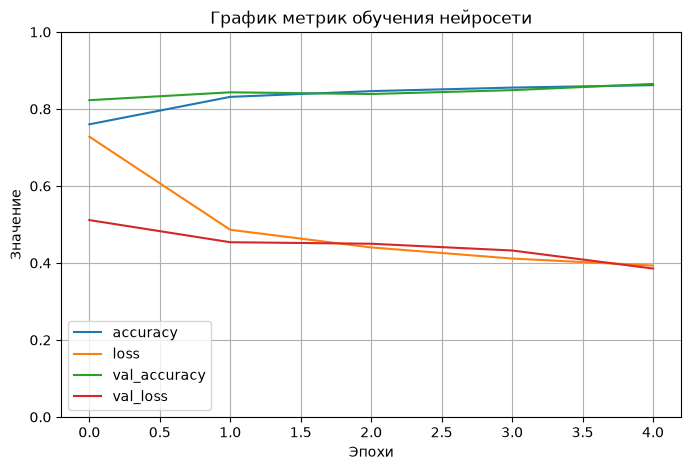

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

Матрица вероятностей для 3-х картинок (результат Softmax):
 [[0.   0.   0.   0.   0.   0.07 0.   0.25 0.   0.67]
 [0.   0.   0.97 0.   0.01 0.   0.02 0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

Предсказанные классы (индексы): [9 2 1]
Предсказанные названия: ['Ботильоны', 'Пуловер', 'Брюки']


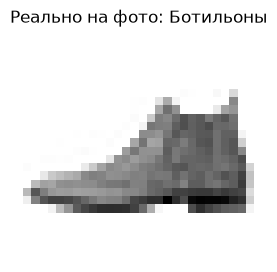

In [4]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("График метрик обучения нейросети")
plt.xlabel("Эпохи")
plt.ylabel("Значение")
plt.show()

X_new = X_test[:3]

y_proba = model.predict(X_new)
print("\nМатрица вероятностей для 3-х картинок (результат Softmax):\n", y_proba.round(2))

y_pred = np.argmax(y_proba, axis=1)
print(f"\nПредсказанные классы (индексы): {y_pred}")
print(f"Предсказанные названия: {[class_names[idx] for idx in y_pred]}")

plt.figure(figsize=(3, 3))
plt.imshow(X_new[0], cmap="binary")
plt.title(f"Реально на фото: {class_names[y_test[0]]}")
plt.axis("off")
plt.show()

In [5]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

model_reg = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_reg.compile(loss="mean_squared_error", optimizer="sgd")

print("Запуск обучения регрессионной нейросети...")
history_reg = model_reg.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

mse_test = model_reg.evaluate(X_test, y_test)
print(f"\nФинальная ошибка MSE на тестовых данных: {mse_test:.4f}")

Запуск обучения регрессионной нейросети...
Epoch 1/10


/usr/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8626 - val_loss: 3.3014
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4668 - val_loss: 1.9246
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4339 - val_loss: 3.3267
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4870 - val_loss: 6.8795
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4448 - val_loss: 3.4199
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4273 - val_loss: 0.3787
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3964 - val_loss: 0.3602
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3900 - val_loss: 0.4154
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3868 - val_loss: 0.3880
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3792 - val_loss: 0.3740
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3716

Финальная ошибка MSE на тестовых данных: 0.3716


In [6]:
input_ = keras.layers.Input(shape=X_train.shape[1:])

hidden1 = keras.layers.Dense(30, activation='relu')(input_)
hidden2 = keras.layers.Dense(30, activation='relu')(hidden1)

concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model_functional = keras.models.Model(inputs = [input_], outputs = [output])

model_functional.summary()

model_functional.compile(loss='mean_squared_error', optimizer=keras.optimizers.SGD(learning_rate=1e-3))

print('Обучения нейронки...')
history_func = model_functional.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30)        │        270 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30)        │        930 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer_2[0]… │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

Обучения нейронки...
Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.2169 - val_loss: 0.8737
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7746 - val_loss: 0.6832
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6747 - val_loss: 0.6146
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6332 - val_loss: 0.6424
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6018 - val_loss: 0.6412
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5749 - val_loss: 0.5509
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5561 - val_loss: 0.5518
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5357 - val_loss: 0.4970
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5194 - val_loss: 0.4927
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5063 - val_loss: 0.4704


In [7]:
tf.random.set_seed(42)

class WideAndDeepModel(keras.Model):
    def __init__(self, units = 30, activation = 'relu', **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.conct = keras.layers.Concatenate()

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = self.conct([input_A, hidden2])
        output = self.main_output(concat)
        return output

model_subclass = WideAndDeepModel(units = 30)

model_subclass.compile(loss='mean_squared_error', optimizer=keras.optimizers.SGD(learning_rate=1e-3))

print('Обучение кастомной модели...')
history_sub = model_subclass.fit((X_train, X_train), y_train, epochs = 5, validation_data=((X_valid, X_valid), y_valid))

Обучение кастомной модели...
Epoch 1/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.1443 - val_loss: 1.0483
Epoch 2/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7166 - val_loss: 0.6832
Epoch 3/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6271 - val_loss: 0.5867
Epoch 4/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6003 - val_loss: 0.5749
Epoch 5/5
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5801 - val_loss: 0.5548


In [8]:
model_reg.save('my_california_model.keras')
print("Модель успешно сохранена в файл 'my_california_model.keras'!")

loaded_model = keras.models.load_model('my_california_model.keras')
print('Модель загружена!')

predictions = loaded_model.predict(X_test[:3])
print("\nПредсказания цен домов от загруженной модели:")
print(predictions.ravel())
print("Реальные цены домов для сравнения:")
print(y_test[:3])

Модель успешно сохранена в файл 'my_california_model.keras'!
Модель загружена!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

Предсказания цен домов от загруженной модели:
[0.6362817 1.6760949 3.6140733]
Реальные цены домов для сравнения:
[0.477   0.458   5.00001]


In [9]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)

print("Запуск обучения с автоматическим сохранением лучшей модели...")
history_with_cb = model_reg.fit(
    X_train, y_train, 
    epochs=10, 
    validation_data=(X_valid, y_valid),
    callbacks=[checkpoint_cb]
)

best_model = keras.models.load_model("best_model.keras")
print("\nУра! Самая точная модель сохранена и готова к работе.")

Запуск обучения с автоматическим сохранением лучшей модели...
Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3772 - val_loss: 0.3808
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3740 - val_loss: 0.3735
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3709 - val_loss: 0.3649
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3688 - val_loss: 0.3574
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3655 - val_loss: 0.3515
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3630 - val_loss: 0.3464
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3607 - val_loss: 0.3418
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3586 - val_loss: 0.3380
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3566 - val_loss: 0.3353
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3545 - val_loss: 0.3456

Ура! Самая точная модель сохранена и готова к работе.


In [10]:
def get_run_logdir():
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(os.curdir, 'my_logs', run_id)

run_logdir = get_run_logdir()
print(f"Логи этого запуска будут сохранены в: {run_logdir}")

tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

print('Обучение нейросети и запись логов...')

hostory_tb = model_reg.fit(
    X_train, y_train,
    epochs =10, 
    validation_data = (X_valid, y_valid),
    callbacks=[tensorboard_cb]
)

Логи этого запуска будут сохранены в: ./my_logs/run_2026_09_25-21_23_24
Обучение нейросети и запись логов...
Epoch 1/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3534 - val_loss: 0.3690
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3516 - val_loss: 0.3479
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3500 - val_loss: 0.3487
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3483 - val_loss: 0.3338
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3464 - val_loss: 0.3287
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3447 - val_loss: 0.3436
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3432 - val_loss: 0.3459
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3422 - val_loss: 0.4654
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3407 - val_loss: 0.3581
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3397 - val_loss: 0.5525


In [11]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs

Reusing TensorBoard on port 6006 (pid 5245), started 0:05:42 ago. (Use '!kill 5245' to kill it.)